C:\Users\b_o_x\AppData\Local\Temp\ipykernel_26976\973503305.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query, conn)
C:\Users\b_o_x\AppData\Local\Temp\ipykernel_26976\973503305.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(hot_encode)


Tamaño matriz transaccional: (31465, 266)

Exp_1_base | support = 0.02 | lift >= 1.2 | confidence >= 0.3


C:\Users\b_o_x\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



Top 10 reglas:
                                           antecedents  \
318  (Long-Sleeve Logo Jersey, M, Long-Sleeve Logo ...   
323   (Sport-100 Helmet, Black, Sport-100 Helmet, Red)   
337    (Sport-100 Helmet, Blue, Sport-100 Helmet, Red)   
332  (Long-Sleeve Logo Jersey, M, Long-Sleeve Logo ...   
307  (Sport-100 Helmet, Black, Sport-100 Helmet, Blue)   
306  (Long-Sleeve Logo Jersey, M, Long-Sleeve Logo ...   
360  (Long-Sleeve Logo Jersey, M, Sport-100 Helmet,...   
365    (Sport-100 Helmet, Blue, Sport-100 Helmet, Red)   
382  (Sport-100 Helmet, Red, AWC Logo Cap, Long-Sle...   
387  (Sport-100 Helmet, Blue, Sport-100 Helmet, Black)   

                                           consequents   support  confidence  \
318   (Sport-100 Helmet, Black, Sport-100 Helmet, Red)  0.020118    0.941964   
323  (Long-Sleeve Logo Jersey, M, Long-Sleeve Logo ...  0.020118    0.799242   
337  (Long-Sleeve Logo Jersey, M, Long-Sleeve Logo ...  0.020054    0.795712   
332    (Sport-100 Helmet,

C:\Users\b_o_x\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
C:\Users\b_o_x\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



Top 10 reglas:
                     antecedents                   consequents   support  \
11            (HL Mountain Tire)          (Mountain Tire Tube)  0.030415   
10          (Mountain Tire Tube)            (HL Mountain Tire)  0.030415   
1   (Long-Sleeve Logo Jersey, L)                (AWC Logo Cap)  0.037248   
0                 (AWC Logo Cap)  (Long-Sleeve Logo Jersey, L)  0.037248   
14            (Road Bottle Cage)       (Water Bottle - 30 oz.)  0.048339   
15       (Water Bottle - 30 oz.)            (Road Bottle Cage)  0.048339   
12        (Mountain Bottle Cage)       (Water Bottle - 30 oz.)  0.053774   
13       (Water Bottle - 30 oz.)        (Mountain Bottle Cage)  0.053774   
2      (Sport-100 Helmet, Black)                (AWC Logo Cap)  0.031400   
4       (Sport-100 Helmet, Blue)                (AWC Logo Cap)  0.032131   

    confidence      lift  
11    0.685530  6.969371  
10    0.309208  6.969371  
1     0.716820  6.669050  
0     0.346541  6.669050  
14    0.8884

C:\Users\b_o_x\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


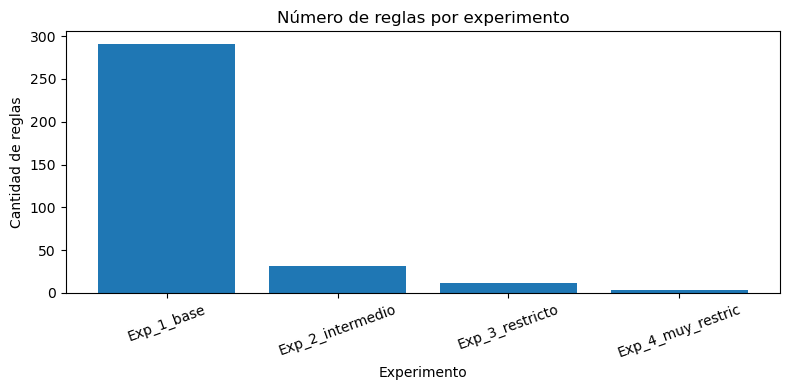

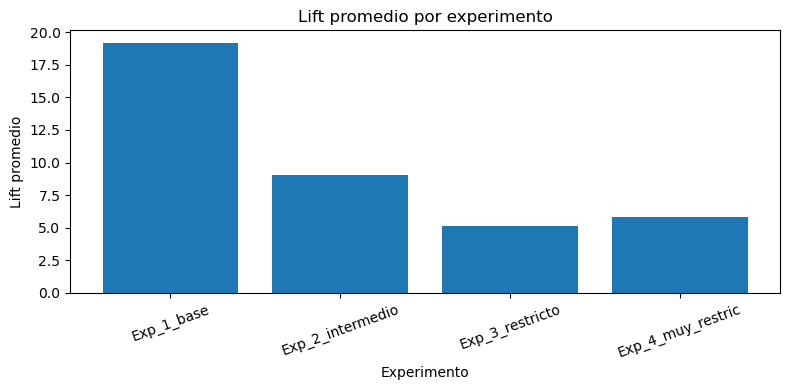

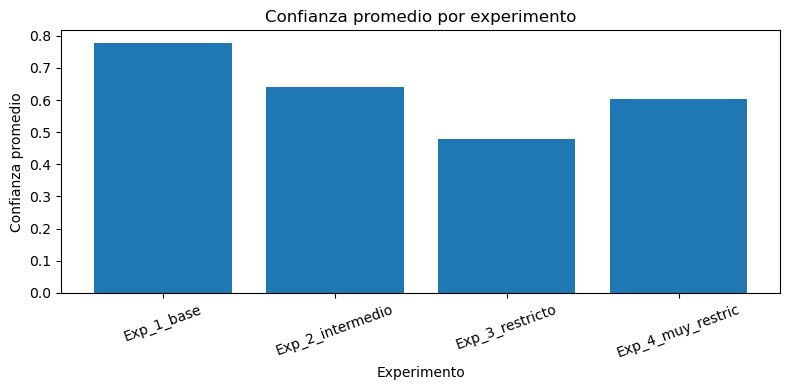


Archivos generados:
resumen_reglas_asociacion_ajustado.xlsx
reglas_por_experimento_ajustado.png
lift_promedio_por_experimento_ajustado.png
confianza_promedio_por_experimento_ajustado.png


In [2]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules

# =====================================================
# 1. CONEXIÓN
# =====================================================
conn = pyodbc.connect(
    'Driver={SQL Server};'
    'Server=DESKTOP-SDA345T\\SQLEXPRESS;'
    'Database=AdventureWorks2019;'
    'Trusted_Connection=yes;'
)

# =====================================================
# 2. CONSULTA SQL
# =====================================================
query = '''
SELECT
     T0.SalesOrderID AS Factura,
     CONVERT(varchar,T1.OrderDate,105) AS Fecha,
     T0.ProductID AS ProductID,
     T2.Name AS Producto,
     T0.OrderQty AS Cantidad,
     T0.UnitPrice AS Precio
FROM [Sales].[SalesOrderDetail] T0
JOIN Sales.SalesOrderHeader T1 
    ON T0.SalesOrderID = T1.SalesOrderID
JOIN Production.Product T2 
    ON T0.ProductID = T2.ProductID
'''

data = pd.read_sql(query, conn)
conn.close()

# =====================================================
# 3. PREPARACIÓN DE DATOS
# =====================================================
data["Producto"] = data["Producto"].str.strip()
data.dropna(axis=0, subset=["Factura"], inplace=True)
data["Factura"] = data["Factura"].astype(str)

basket = (
    data
    .groupby(["Factura", "Producto"])["Cantidad"]
    .sum()
    .unstack()
    .fillna(0)
)

def hot_encode(x):
    if x <= 0:
        return 0
    else:
        return 1

basket = basket.applymap(hot_encode)

print("Tamaño matriz transaccional:", basket.shape)

# =====================================================
# 4. EXPERIMENTOS AJUSTADOS
# =====================================================
experimentos = [
    {"nombre": "Exp_1_base",        "min_support": 0.020, "min_lift": 1.20, "min_confidence": 0.30},
    {"nombre": "Exp_2_intermedio",  "min_support": 0.025, "min_lift": 1.50, "min_confidence": 0.30},
    {"nombre": "Exp_3_restricto",   "min_support": 0.030, "min_lift": 2.00, "min_confidence": 0.30},
    {"nombre": "Exp_4_muy_restric", "min_support": 0.040, "min_lift": 2.50, "min_confidence": 0.30},
]

resumen = []
top_rules_por_exp = {}

for exp in experimentos:

    print("\n" + "="*70)
    print(
        exp["nombre"],
        "| support =", exp["min_support"],
        "| lift >=", exp["min_lift"],
        "| confidence >=", exp["min_confidence"]
    )
    print("="*70)

    frq_items = apriori(
        basket,
        min_support=exp["min_support"],
        use_colnames=True
    )

    if len(frq_items) > 0:
        rules = association_rules(
            frq_items,
            metric="lift",
            min_threshold=exp["min_lift"]
        )

        rules = rules[
            (rules["confidence"] >= exp["min_confidence"]) &
            (rules["lift"] >= exp["min_lift"])
        ]

        rules = rules.sort_values(
            ["lift", "confidence"],
            ascending=[False, False]
        )
    else:
        rules = pd.DataFrame()

    n_itemsets = len(frq_items)
    n_rules = len(rules)

    if n_rules > 0:
        avg_lift = rules["lift"].mean()
        avg_confidence = rules["confidence"].mean()
        max_lift = rules["lift"].max()
        max_confidence = rules["confidence"].max()
        top_rules = rules.head(10)

        print("\nTop 10 reglas:")
        print(top_rules[["antecedents", "consequents", "support", "confidence", "lift"]])
    else:
        avg_lift = 0
        avg_confidence = 0
        max_lift = 0
        max_confidence = 0
        top_rules = pd.DataFrame()

        print("\nNo se generaron reglas útiles con esta configuración.")

    resumen.append({
        "experimento": exp["nombre"],
        "min_support": exp["min_support"],
        "min_lift": exp["min_lift"],
        "min_confidence": exp["min_confidence"],
        "n_itemsets": n_itemsets,
        "n_rules": n_rules,
        "avg_lift": avg_lift,
        "avg_confidence": avg_confidence,
        "max_lift": max_lift,
        "max_confidence": max_confidence
    })

    top_rules_por_exp[exp["nombre"]] = top_rules

# =====================================================
# 5. RESUMEN COMPARATIVO
# =====================================================
resumen_df = pd.DataFrame(resumen)

resumen_df["score"] = (
    resumen_df["avg_lift"] * 0.45 +
    resumen_df["avg_confidence"] * 0.45 +
    np.log1p(resumen_df["n_rules"]) * 0.10
)

print("\n" + "="*70)
print("RESUMEN EXPERIMENTACIÓN AJUSTADA")
print("="*70)
print(resumen_df)

mejor = resumen_df[resumen_df["n_rules"] > 0].sort_values(
    by="score",
    ascending=False
).iloc[0]

print("\nMEJOR EXPERIMENTO:")
print(mejor)

# =====================================================
# 6. GRÁFICOS
# =====================================================
plt.figure(figsize=(8, 4))
plt.bar(resumen_df["experimento"], resumen_df["n_rules"])
plt.title("Número de reglas por experimento")
plt.xlabel("Experimento")
plt.ylabel("Cantidad de reglas")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("reglas_por_experimento_ajustado.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(resumen_df["experimento"], resumen_df["avg_lift"])
plt.title("Lift promedio por experimento")
plt.xlabel("Experimento")
plt.ylabel("Lift promedio")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("lift_promedio_por_experimento_ajustado.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(resumen_df["experimento"], resumen_df["avg_confidence"])
plt.title("Confianza promedio por experimento")
plt.xlabel("Experimento")
plt.ylabel("Confianza promedio")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("confianza_promedio_por_experimento_ajustado.png", dpi=300)
plt.show()

# =====================================================
# 7. EXPORTAR RESULTADOS
# =====================================================
resumen_df.to_excel("resumen_reglas_asociacion_ajustado.xlsx", index=False)

for nombre, reglas in top_rules_por_exp.items():
    if len(reglas) > 0:
        reglas.to_excel(f"top_rules_{nombre}.xlsx", index=False)

print("\nArchivos generados:")
print("resumen_reglas_asociacion_ajustado.xlsx")
print("reglas_por_experimento_ajustado.png")
print("lift_promedio_por_experimento_ajustado.png")
print("confianza_promedio_por_experimento_ajustado.png")